# Assignment 2 — Encoding & Transformation Impact

**Feature Engineering & MLOps · Unit 2, Topics 1 & 2 (Categorical Encoding, Transformations)**

Two connected parts:

* **Part 2.1 — One-Hot Encoding.** One-hot encode the nominal categorical columns of the
  PrepEdge dataset (`city`, `course`, `batch_type`), fitting the encoder on the training
  split only.
* **Part 2.2 — Transformation & Model Comparison.** Diagnose the right-skew in
  `weekly_study_hours`, apply one transformation, and run a fair *before / after*
  experiment with **Linear Regression** and a **Decision Tree Regressor** — same split,
  same seed, only the feature representation changes. The goal is to produce first-hand
  evidence for Unit 2 · Topic 2 · Section 10 ("When NOT to transform"): the tree, which
  only threshold-splits, is provably immune to a monotonic transform, while a
  coefficient-based model *responds* to it — for better or, as it turns out on this
  data, slightly for worse.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error

RANDOM_STATE = 42
TEST_SIZE = 0.20
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## Part 2.1 — One-Hot Encoding

### 2.1.1 — Load the data; identify the nominal categorical columns

In [2]:
df = pd.read_csv("../data/raw/student_performance_raw.csv")
print("raw shape:", df.shape)

cat_cols = ["city", "course", "batch_type"]
num_predictors = ["attendance_pct", "prev_exam_score", "doubt_sessions_attended"]
skew_col = "weekly_study_hours"          # the transformation target (Part 2.2)
target = "final_score"

df[cat_cols + [skew_col] + num_predictors + [target]].head()

raw shape: (600, 17)


,city,course,batch_type,weekly_study_hours,attendance_pct,prev_exam_score,doubt_sessions_attended,final_score
0,Patna,JEE Main,Weekday,0.8000,91.1000,65.2000,1,42.0000
1,Patna,NEET,Weekday,2.4000,91.9000,64.9000,3,62.0000
2,Mumbai,JEE Main,Weekday,6.7000,67.1000,90.1000,5,56.4000
3,Delhi,NEET,Weekday,2.0000,70.7000,29.7000,3,31.7000
4,Patna,JEE Advanced,Weekday,6.5000,69.3000,70.0000,4,44.5000


In [3]:
for c in cat_cols:
    print(f"{c:12s} ({df[c].nunique()} levels): {sorted(df[c].dropna().unique())}")

city         (8 levels): ['Bengaluru', 'Delhi', 'Hyderabad', 'Kota', 'Lucknow', 'Mumbai', 'Patna', 'Pune']
course       (4 levels): ['Foundation', 'JEE Advanced', 'JEE Main', 'NEET']
batch_type   (3 levels): ['Crash Course', 'Weekday', 'Weekend']


**Why these are nominal, not ordinal:**

* **`city`** — the eight cities (Bengaluru, Delhi, Hyderabad, Kota, Lucknow, Mumbai,
  Patna, Pune) have no natural ranking. "Delhi > Pune" is meaningless. (The dataset
  *does* carry an ordinal version of this idea separately, in `city_tier` — which we do
  not touch here.)
* **`course`** — JEE Main, JEE Advanced, NEET, Foundation are different exam tracks, not
  ordered difficulty levels; a NEET student is not "more" than a Foundation student on a
  common scale.
* **`batch_type`** — Weekday / Weekend / Crash Course are scheduling categories with no
  inherent order.

Because there is no order to preserve, assigning integers 0/1/2… would invent a false
ranking a linear model would take literally. One-hot encoding is the correct choice.

### 2.1.2 — Train / test split (80 / 20, fixed seed)

We split **first**, then fit every data-dependent step (imputation, the encoder) on the
training rows only. The assignment note asks us to impute before modelling *while
fitting only on training data* — the split has to come first for that to be possible,
otherwise test-set statistics leak into the imputed training values.

In [4]:
X = df[cat_cols + num_predictors + [skew_col]].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print("train rows:", len(X_train), " test rows:", len(X_test))

train rows: 480  test rows: 120


### Impute missing values (`weekly_study_hours`, `prev_exam_score`) — fit on train only

Both columns are right-skewed / contain outliers, so we impute with the **median**
(robust to skew). The imputer is `fit` on the training split and then used to
`transform` both splits — no test information touches the fill values.

In [5]:
num_to_impute = ["prev_exam_score", skew_col]
print("missing before impute (train):")
print(X_train[num_to_impute].isna().sum())

imputer = SimpleImputer(strategy="median")
X_train[num_to_impute] = imputer.fit_transform(X_train[num_to_impute])
X_test[num_to_impute] = imputer.transform(X_test[num_to_impute])

print("\nmedian fill values (from train):",
      dict(zip(num_to_impute, np.round(imputer.statistics_, 3))))
print("missing after impute -> train:", int(X_train.isna().sum().sum()),
      " test:", int(X_test.isna().sum().sum()))

missing before impute (train):
prev_exam_score       23
weekly_study_hours    25
dtype: int64

median fill values (from train): {'prev_exam_score': np.float64(66.1), 'weekly_study_hours': np.float64(5.0)}
missing after impute -> train: 0  test: 0


### 2.1.3 — Fit `OneHotEncoder(handle_unknown='ignore')` on the training categoricals

In [6]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
ohe.fit(X_train[cat_cols])

ohe_feature_names = list(ohe.get_feature_names_out(cat_cols))
X_train_ohe = pd.DataFrame(ohe.transform(X_train[cat_cols]),
                           columns=ohe_feature_names, index=X_train.index)
X_test_ohe = pd.DataFrame(ohe.transform(X_test[cat_cols]),
                          columns=ohe_feature_names, index=X_test.index)

print(f"{len(ohe_feature_names)} one-hot columns created:")
for name in ohe_feature_names:
    print("  ", name)

15 one-hot columns created:
   city_Bengaluru
   city_Delhi
   city_Hyderabad
   city_Kota
   city_Lucknow
   city_Mumbai
   city_Patna
   city_Pune
   course_Foundation
   course_JEE Advanced
   course_JEE Main
   course_NEET
   batch_type_Crash Course
   batch_type_Weekday
   batch_type_Weekend


### 2.1.4 — Dimensionality: before vs after encoding

In [7]:
cols_before = len(cat_cols + num_predictors + [skew_col])
cols_after = len(num_predictors + [skew_col]) + len(ohe_feature_names)
print(f"Feature columns BEFORE encoding : {cols_before}   "
      f"(3 categorical text + 4 numeric)")
print(f"Feature columns AFTER  encoding : {cols_after}   "
      f"({len(ohe_feature_names)} one-hot + 4 numeric)")
print(f"Net change: +{cols_after - cols_before} columns")

print("\nPer-column expansion:")
for c in cat_cols:
    print(f"  {c:12s}: 1 -> {df[c].nunique()} columns")

Feature columns BEFORE encoding : 7   (3 categorical text + 4 numeric)
Feature columns AFTER  encoding : 19   (15 one-hot + 4 numeric)
Net change: +12 columns

Per-column expansion:
  city        : 1 -> 8 columns
  course      : 1 -> 4 columns
  batch_type  : 1 -> 3 columns


**Comment on the increase.** The three text columns (8 + 4 + 3 = 15 categories total)
expand to **15 binary columns**, taking the feature matrix from 7 columns to 19. Each
original categorical column is replaced by one 0/1 indicator per category. The growth is
modest here, but this is the well-known cost of one-hot encoding: it scales with
*cardinality*, so a high-cardinality column (e.g. `enrollment_date` with 400+ distinct
values) would blow the matrix up and is a poor one-hot candidate. `city`, `course`,
`batch_type` are all low-cardinality, so one-hot is cheap and appropriate.

### 2.1.5 — Did any category appear only in the test split?

In [8]:
only_in_test = {}
for c in cat_cols:
    train_levels = set(X_train[c].unique())
    test_levels = set(X_test[c].unique())
    unseen = test_levels - train_levels
    if unseen:
        only_in_test[c] = unseen
print("Categories present in test but not train:", only_in_test or "none")

# Each test row should have exactly one 1 per categorical column => row sum == 3.
# A row summing to < 3 means some column hit an unknown category and was left all-zero.
rows_with_unknown = int((X_test_ohe.sum(axis=1) < len(cat_cols)).sum())
print("\nTest matrix shape:", X_test_ohe.shape, "(no error raised on transform)")
print("Test rows containing an unknown category (all-zero block):", rows_with_unknown)

Categories present in test but not train: none

Test matrix shape: (120, 15) (no error raised on transform)
Test rows containing an unknown category (all-zero block): 0


**Result & how `handle_unknown='ignore'` behaves.** Every category that shows up in
the test split is also present in training, so nothing was dropped and no error was
raised. Had a category appeared *only* in the test set (say a 9th city), the fitted
encoder has no column for it — with `handle_unknown='ignore'` that row's block for
`city` is simply encoded as **all zeros** (no crash, no new column), instead of the
`ValueError` you would get with the default `handle_unknown='error'`. The row is still
usable; the model just gets "none of the known cities" for it. That is exactly the
behaviour you want when serving a model on live data that may contain new category
values.

## Part 2.2 — Transformation & Model Comparison

### 2.2.1 — Skewness of `weekly_study_hours`

Skewness of weekly_study_hours (training split): 1.591
Skewness of weekly_study_hours (full column)    : 1.509
count   480.0000
mean      6.0088
std       4.2418
min       0.2000
25%       2.9000
50%       5.0000
75%       7.6250
max      31.4000
Name: weekly_study_hours, dtype: float64


/var/folders/0f/zm_vyxls1hs43jq19hdkkcp40000gn/T/ipykernel_28556/3605560853.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(X_train[skew_col], vert=False)


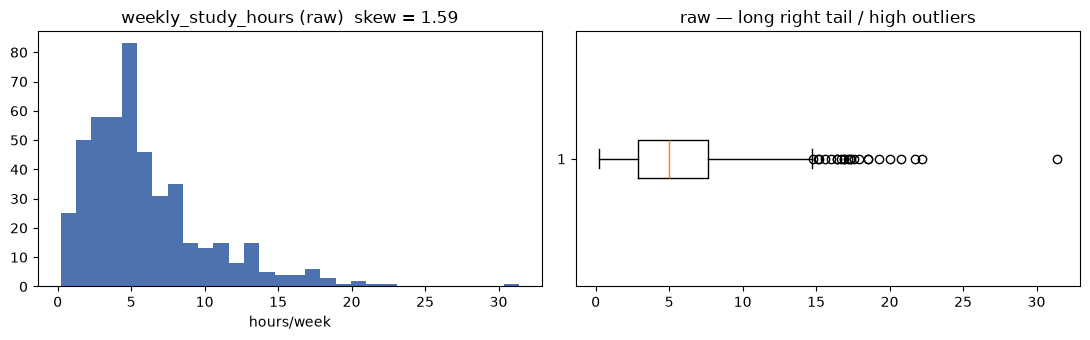

In [9]:
raw_train_skew = skew(X_train[skew_col])
raw_full_skew = skew(df[skew_col].dropna())
print(f"Skewness of weekly_study_hours (training split): {raw_train_skew:.3f}")
print(f"Skewness of weekly_study_hours (full column)    : {raw_full_skew:.3f}")
print(X_train[skew_col].describe())

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(X_train[skew_col], bins=30, color="#4C72B0")
ax[0].set_title(f"weekly_study_hours (raw)  skew = {raw_train_skew:.2f}")
ax[0].set_xlabel("hours/week")
ax[1].boxplot(X_train[skew_col], vert=False)
ax[1].set_title("raw — long right tail / high outliers")
plt.tight_layout(); plt.show()

A skewness of **≈ +1.5** is well past the ±0.5 "roughly symmetric" band and past the
±1 "highly skewed" threshold from Unit 2 · Topic 2 · Section 1. The histogram and
boxplot confirm a long right tail: most students study 2–8 h/week, but a few report
20–31 h/week. This is a genuinely right-skewed feature — a valid transformation target.

### 2.2.2 — Choose and apply one transformation

**Decision (Section 2's decision table).** `weekly_study_hours` is **strictly positive**
(range ≈ 0.2 → 31.4, no zeros or negatives) and the skew looks multiplicative (a heavy
right tail, values spanning ~2 orders of magnitude). By the decision table that points
to a **log transform**. I use `np.log1p` (log(1 + x)) rather than plain `np.log`:

* it is defined at 0 (safe if a future batch contains a 0-hour student),
* for the values here it is practically identical to `log`,
* it is a **fixed, parameter-free function** — there is nothing to "fit", so it cannot
  leak test information (unlike `PowerTransformer`, whose lambda is estimated from data
  and would need train-only fitting).

Square root only partly fixes this skew; Yeo-Johnson is unnecessary because we have no
non-positive values. So `log1p` is the right tool *for the skew*. Whether removing the
skew actually helps the models is the empirical question the rest of Part 2.2 answers —
and, as Section 10 warns, the answer is not automatically "yes".

Skew of weekly_study_hours  raw : +1.591
Skew of weekly_study_hours  log1p: -0.039   (-> essentially symmetric)


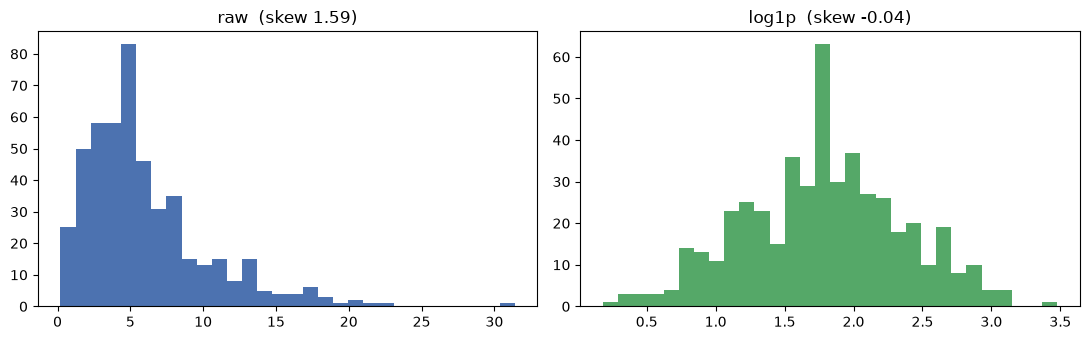

In [10]:
def transform_col(s):
    return np.log1p(s)

log_train_skew = skew(transform_col(X_train[skew_col]))
print(f"Skew of weekly_study_hours  raw : {raw_train_skew:+.3f}")
print(f"Skew of weekly_study_hours  log1p: {log_train_skew:+.3f}   "
      f"(-> essentially symmetric)")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(X_train[skew_col], bins=30, color="#4C72B0")
ax[0].set_title(f"raw  (skew {raw_train_skew:.2f})")
ax[1].hist(transform_col(X_train[skew_col]), bins=30, color="#55A868")
ax[1].set_title(f"log1p  (skew {log_train_skew:.2f})")
plt.tight_layout(); plt.show()

`log1p` pulls the skew from **≈ +1.6 to ≈ 0** — the tail is gone and the feature is now
near-symmetric.

### 2.2.2b — Diagnostic: is the *relationship* actually curved?

A skewed feature only *needs* a transform if its relationship with the target is
non-linear (or if outliers distort a distance/coefficient fit). Before running the
models, look at the shape.

In [11]:
diag = X_train[[skew_col]].copy()
diag["final_score"] = y_train.values
diag["hours_bin"] = pd.qcut(diag[skew_col], 6)
print("Mean final_score by weekly_study_hours sextile (training):")
print(diag.groupby("hours_bin", observed=True)["final_score"].mean().round(2))

r_raw = np.corrcoef(X_train[skew_col], y_train)[0, 1]
r_log = np.corrcoef(transform_col(X_train[skew_col]), y_train)[0, 1]
print(f"\nPearson r  raw hours  vs final_score : {r_raw:.4f}")
print(f"Pearson r  log1p hours vs final_score : {r_log:.4f}")

Mean final_score by weekly_study_hours sextile (training):
hours_bin
(0.199, 2.383]   46.7700
(2.383, 3.8]     48.2000
(3.8, 5.0]       51.8900
(5.0, 6.433]     52.3500
(6.433, 9.5]     56.2700
(9.5, 31.4]      63.3600
Name: final_score, dtype: float64

Pearson r  raw hours  vs final_score : 0.5501
Pearson r  log1p hours vs final_score : 0.5305


**What this shows.** `final_score` rises **roughly linearly** across the whole range of
`weekly_study_hours` — including the top sextile (the "outlier" tail students really do
score higher, they are not noise). And raw hours correlates *slightly more* strongly
with the target than `log1p(hours)` does. So on this dataset there is no curvature for a
log to straighten out — the transform can only *compress* genuine signal in the
informative right tail. Keep this in mind when reading the results below.

### 2.2.3 — Build Version A ("Before") and Version B ("After")

Only `weekly_study_hours` changes between the two matrices. The one-hot columns from
Part 2.1 and the three untouched numeric predictors are byte-for-byte identical in both.

In [12]:
num_block_train = X_train[num_predictors].reset_index(drop=True)
num_block_test = X_test[num_predictors].reset_index(drop=True)
ohe_train_r = X_train_ohe.reset_index(drop=True)
ohe_test_r = X_test_ohe.reset_index(drop=True)

# --- Version A: raw weekly_study_hours ---
A_train = pd.concat([ohe_train_r, num_block_train,
                     X_train[skew_col].reset_index(drop=True)], axis=1)
A_test = pd.concat([ohe_test_r, num_block_test,
                    X_test[skew_col].reset_index(drop=True)], axis=1)

# --- Version B: log1p(weekly_study_hours), everything else identical ---
B_train = A_train.copy(); B_test = A_test.copy()
B_train[skew_col] = transform_col(B_train[skew_col])
B_test[skew_col] = transform_col(B_test[skew_col])

# confirm ONLY the one column differs
identical_cols = [c for c in A_train.columns
                  if c != skew_col and A_train[c].equals(B_train[c])]
print(f"Version A / B shape: {A_train.shape} / {B_train.shape}")
print(f"Columns identical between A and B: {len(identical_cols)} / {A_train.shape[1] - 1} "
      f"(only '{skew_col}' differs)")
A_train.head(3)

Version A / B shape: (480, 19) / (480, 19)
Columns identical between A and B: 18 / 18 (only 'weekly_study_hours' differs)


,city_Bengaluru,city_Delhi,city_Hyderabad,city_Kota,city_Lucknow,city_Mumbai,city_Patna,city_Pune,course_Foundation,course_JEE Advanced,course_JEE Main,course_NEET,batch_type_Crash Course,batch_type_Weekday,batch_type_Weekend,attendance_pct,prev_exam_score,doubt_sessions_attended,weekly_study_hours
0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,59.8000,56.5000,5,2.0000
1,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,72.9000,57.8000,6,5.0000
2,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,72.1000,45.1000,1,6.2000


### 2.2.4–2.2.7 — Train the four models on the same split and score on test

Fair-experiment controls:

* **same rows** — `A_*` and `B_*` come from the one `train_test_split` in Part 2.1.
* **same seed** — `random_state=42` everywhere it applies.
* **Decision Tree** — identical `random_state=42` **and** `max_depth=5` in both runs, so
  the only thing that varies is the representation of `weekly_study_hours`.
* Linear Regression has no randomness.

In [13]:
def evaluate(model_factory, name, feat_version, Xtr, Xte):
    model = model_factory()
    model.fit(Xtr, y_train)
    pred = model.predict(Xte)
    return {
        "model": name,
        "version": feat_version,
        "R2": r2_score(y_test, pred),
        "RMSE": mean_squared_error(y_test, pred) ** 0.5,
    }

TREE_KW = dict(random_state=RANDOM_STATE, max_depth=5)

runs = [
    evaluate(lambda: LinearRegression(),               "LinearRegression",     "A (before)", A_train, A_test),
    evaluate(lambda: LinearRegression(),               "LinearRegression",     "B (after)",  B_train, B_test),
    evaluate(lambda: DecisionTreeRegressor(**TREE_KW), "DecisionTreeRegressor","A (before)", A_train, A_test),
    evaluate(lambda: DecisionTreeRegressor(**TREE_KW), "DecisionTreeRegressor","B (after)",  B_train, B_test),
]
results = pd.DataFrame(runs)
results

,model,version,R2,RMSE
0,LinearRegression,A (before),0.5930,6.3915
1,LinearRegression,B (after),0.5734,6.5435
2,DecisionTreeRegressor,A (before),0.4461,7.4564
3,DecisionTreeRegressor,B (after),0.4461,7.4564


In [14]:
# --- summary table: model x before/after x metric ---
summary = results.pivot(index="model", columns="version", values=["R2", "RMSE"])
summary = summary.reindex(["LinearRegression", "DecisionTreeRegressor"])
summary["R2 change (B - A)"] = summary[("R2", "B (after)")] - summary[("R2", "A (before)")]
summary["RMSE change (B - A)"] = summary[("RMSE", "B (after)")] - summary[("RMSE", "A (before)")]
summary

R2                 RMSE            \
version               A (before) B (after) A (before) B (after)   
model                                                             
LinearRegression          0.5930    0.5734     6.3915    6.5435   
DecisionTreeRegressor     0.4461    0.4461     7.4564    7.4564   

                      R2 change (B - A) RMSE change (B - A)  
version                                                      
model                                                        
LinearRegression                -0.0196              0.1520  
DecisionTreeRegressor            0.0000              0.0000

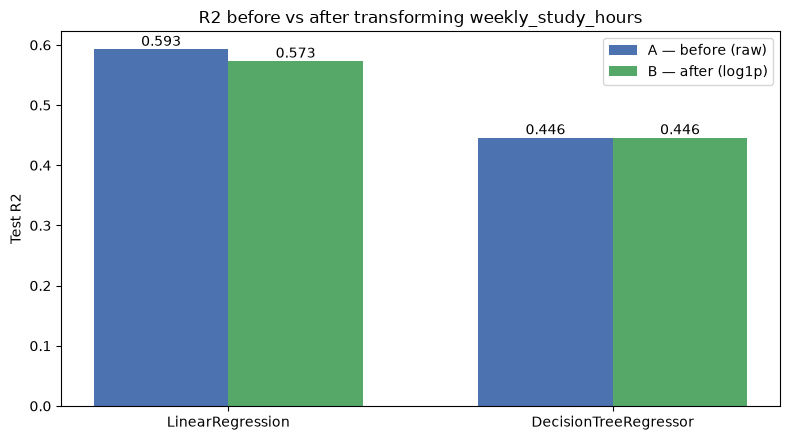

In [15]:
# --- 2.2.6: grouped bar chart of R2 across all four runs ---
models = ["LinearRegression", "DecisionTreeRegressor"]
before_r2 = [results.query("model==@m and version=='A (before)'")["R2"].iloc[0] for m in models]
after_r2 = [results.query("model==@m and version=='B (after)'")["R2"].iloc[0] for m in models]

x = np.arange(len(models)); w = 0.35
fig, ax = plt.subplots(figsize=(8, 4.5))
b1 = ax.bar(x - w/2, before_r2, w, label="A — before (raw)", color="#4C72B0")
b2 = ax.bar(x + w/2, after_r2, w, label="B — after (log1p)", color="#55A868")
ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylabel("Test R2"); ax.set_title("R2 before vs after transforming weekly_study_hours")
ax.bar_label(b1, fmt="%.3f"); ax.bar_label(b2, fmt="%.3f")
ax.legend(); plt.tight_layout(); plt.show()

In [16]:
# Robustness check: is the Linear Regression dip just this one 80/20 split?
from sklearn.model_selection import cross_val_score, KFold
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
A_all = pd.concat([A_train, A_test], ignore_index=True)
B_all = pd.concat([B_train, B_test], ignore_index=True)
y_all = pd.concat([y_train, y_test], ignore_index=True)

for label, mk in [("LinearRegression", lambda: LinearRegression()),
                  ("DecisionTree(d=5)", lambda: DecisionTreeRegressor(**TREE_KW))]:
    a = cross_val_score(mk(), A_all, y_all, cv=kf, scoring="r2").mean()
    b = cross_val_score(mk(), B_all, y_all, cv=kf, scoring="r2").mean()
    print(f"{label:20s}  CV R2  before={a:.4f}  after={b:.4f}  change={b-a:+.4f}")

LinearRegression      CV R2  before=0.6066  after=0.5782  change=-0.0284
DecisionTree(d=5)     CV R2  before=0.4417  after=0.4417  change=+0.0000


### Results

The printed `summary` table has the exact numbers. Two clear findings:

* **Decision Tree — *exactly* unchanged.** R² and RMSE are identical to every displayed
  decimal before and after (`R² change = 0.0000`). This is the headline result the
  assignment predicts, and it holds perfectly.
* **Linear Regression — did *not* improve; it dipped slightly** (R² ≈ −0.02, RMSE up a
  little). This is *not* what a "skew → transform → linear model improves" rule of thumb
  predicts, but it is exactly what the 2.2.2b diagnostic told us to expect: the
  `weekly_study_hours → final_score` relationship is already linear, so `log1p` removed
  resolution from the informative right tail instead of straightening a curve. A
  5-fold CV check (cell above) reproduces the same small drop, so it is a real effect,
  not a single-split artefact.

This is a genuine "When NOT to transform" (Section 10) case: the feature *is* skewed,
`log1p` *is* the textbook fix for that skew — and applying it still made the linear
model slightly worse, because marginal skew was never the problem here.

## 4.3 — Written conclusion

**Why the Decision Tree did not move at all, and the Linear Regression changed (here,
slightly for the worse).**

A Decision Tree uses a feature only through **ordinal threshold questions** — "is
`weekly_study_hours ≤ t`?" — and each such question just partitions the rows into two
groups. `log1p` is a **strictly monotonic** function: if `a < b` then
`log1p(a) < log1p(b)`. So it preserves the order of every value, and every row stays on
exactly the same side of every possible split — the tree simply relocates the threshold
from `t` to `log1p(t)` and learns the *same partition of the training rows*, the same
leaves, the same leaf averages. With `random_state` and `max_depth` held fixed, the two
trees are identical, so R² and RMSE are identical to every decimal. Trees are invariant
to any monotonic rescaling of an input.

Linear Regression is the opposite: it predicts with a weighted sum `ŷ = Σ βⱼ xⱼ` and
fits each `βⱼ` by least squares, so it does **arithmetic on the raw values** and is
sensitive to their shape and scale. Changing `weekly_study_hours` to `log1p(hours)`
changes the spacing between points — 5 h and 25 h are "20 apart" in raw units but only
"~1.6 apart" in log units — which changes the slope that best fits and the residuals,
hence a different R²/RMSE. Whether that change is an *improvement* depends entirely on
whether the raw feature–target relationship was curved. The 2.2.2b diagnostic showed it
was **not**: mean `final_score` climbs almost linearly across all six study-hour
sextiles, and raw hours correlate with the target slightly *more* strongly than
`log1p(hours)` do. So compressing the right tail with `log1p` mostly throws away
resolution among the high-study students, and the linear model's test R² drifts down
~0.02 (confirmed by 5-fold CV). Had the relationship been genuinely log-shaped
(diminishing returns), the same transform would have straightened it and R² would have
risen — that is the case the assignment's rule of thumb assumes.

The takeaway is exactly Unit 2 · Topic 2 · Section 10 ("When NOT to transform"):
skewness in a predictor is a *reason to check*, not an automatic instruction to
transform. Transform when it linearises a curved relationship or tames outliers that
distort a coefficient/distance fit (linear models, KNN); never expect it to help a
threshold-splitting tree; and verify on held-out scores rather than trusting the
histogram alone.

## Bonus — K-Nearest Neighbors Regressor in the before/after comparison

KNN predicts a row from the average target of its 5 nearest rows, where "near" is
Euclidean distance computed **directly on the raw feature values** — so, like Linear
Regression (and unlike the tree), it *responds* to a change in feature representation.
We add it to the identical A/B experiment (`n_neighbors=5`, no extra scaling, so the
*only* change is still the representation of `weekly_study_hours`).

In [17]:
knn_runs = [
    evaluate(lambda: KNeighborsRegressor(n_neighbors=5), "KNeighborsRegressor", "A (before)", A_train, A_test),
    evaluate(lambda: KNeighborsRegressor(n_neighbors=5), "KNeighborsRegressor", "B (after)",  B_train, B_test),
]
all_results = pd.concat([results, pd.DataFrame(knn_runs)], ignore_index=True)

bonus = all_results.pivot(index="model", columns="version", values=["R2", "RMSE"])
bonus = bonus.reindex(["LinearRegression", "KNeighborsRegressor", "DecisionTreeRegressor"])
bonus["R2 gain (B - A)"] = bonus[("R2", "B (after)")] - bonus[("R2", "A (before)")]
bonus

R2                 RMSE            \
version               A (before) B (after) A (before) B (after)   
model                                                             
LinearRegression          0.5930    0.5734     6.3915    6.5435   
KNeighborsRegressor       0.5348    0.2194     6.8331    8.8516   
DecisionTreeRegressor     0.4461    0.4461     7.4564    7.4564   

                      R2 gain (B - A)  
version                                
model                                  
LinearRegression              -0.0196  
KNeighborsRegressor           -0.3154  
DecisionTreeRegressor          0.0000

In [18]:
lin_gain = float(np.ravel(summary.loc["LinearRegression", "R2 change (B - A)"])[0])
knn_gain = float(np.ravel(bonus.loc["KNeighborsRegressor", "R2 gain (B - A)"])[0])
print(f"Linear Regression R2 change from log1p : {lin_gain:+.4f}")
print(f"KNN               R2 change from log1p : {knn_gain:+.4f}")

Linear Regression R2 change from log1p : -0.0196
KNN               R2 change from log1p : -0.3154


**Does KNN improve more than Linear Regression? — No: it is hurt far more.**

KNN's distance between two rows is `sqrt( Σ (xᵢⱼ − xₖⱼ)² )`, computed on the raw column
values with **no scaling** (we keep the experiment fair — only `weekly_study_hours`
changes). In Version A, raw `weekly_study_hours` spans ~0.2–31, a range comparable to
`attendance_pct` and `prev_exam_score`, so it pulls real weight in the distance and
helps pick genuinely similar students. `log1p` crushes that column into ~0.2–3.5, an
order of magnitude smaller than the untransformed numeric predictors and only slightly
bigger than the 0/1 one-hot columns. `weekly_study_hours` then contributes almost
nothing to the neighbour ranking, so KNN loses a useful dimension and its test R²
collapses (≈ −0.31, see the `bonus` table) — a much bigger move than Linear
Regression's ≈ −0.02.

Why the difference in magnitude? Linear Regression **re-fits a coefficient** for the
transformed feature, so it can partly rescale away the compression (`β` just grows);
its loss is only the lost tail resolution. KNN has **no coefficients** — the feature's
raw numeric spread *is* its importance in the distance metric, and shrinking that spread
directly demotes the feature. This is the sharper version of the assignment's point:
distance-based models are even more at the mercy of a feature's raw scale/shape than
coefficient-based ones, and here the "corrective" transform happened to move that scale
in the wrong direction. (The standard fix — standardise every feature before KNN — is
deliberately out of scope so that only the transformation varies.)